## KNN Recommendation Model

In [1]:
# import
import numpy as np
import pandas as pd
import requests
from io import BytesIO
from PIL import Image

import torch
import torch.nn as nn

from sklearn.neighbors import NearestNeighbors
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

In [2]:
df = pd.read_csv('/content/final_df.csv')
df.head()

,Unnamed: 0,filename,link,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_data
0,0,1638,http://assets.myntassets.com/v1/images/style/p...,1638,Unisex,Apparel,Bottomwear,Swimwear,Blue,Fall,2010.0,Sports,Nabaiji Swimming Goggles Blue Black,<PIL.Image.Image image mode=RGB size=1800x2400...
1,1,32903,http://assets.myntassets.com/v1/images/style/p...,32903,Women,Apparel,Bottomwear,Shorts,Red,Summer,2012.0,Casual,Allen Solly Women Red Shorts,<PIL.Image.Image image mode=RGB size=1080x1440...
2,2,39381,http://assets.myntassets.com/v1/images/style/p...,39381,Men,Apparel,Bottomwear,Jeans,Black,Summer,2012.0,Casual,Peter England Men Party Black Jeans,<PIL.Image.Image image mode=RGB size=1800x2400...
3,3,12163,http://assets.myntassets.com/v1/images/style/p...,12163,Women,Apparel,Bottomwear,Leggings,Purple,Fall,2011.0,Ethnic,Aurelia Women Solid Purple Leggings,<PIL.Image.Image image mode=RGB size=1800x2400...
4,4,1607,http://assets.myntassets.com/v1/images/style/p...,1607,Men,Apparel,Bottomwear,Track Pants,Blue,Fall,2010.0,Sports,Reebok Men trackpant- male Track Pants,<PIL.Image.Image image mode=RGB size=1080x1440...


In [3]:
# dataframe
print(df.columns)
print(df.shape)

Index(['Unnamed: 0', 'filename', 'link', 'id', 'gender', 'masterCategory',
       'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage',
       'productDisplayName', 'image_data'],
      dtype='object')
(1500, 14)


In [4]:
# image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])])

In [5]:
# combined label
df["img_label"] = df["subCategory"] + " " + df["season"] + " " + df["gender"]
df[["subCategory", "season", "gender", "img_label"]].head()

,subCategory,season,gender,img_label
0,Bottomwear,Fall,Unisex,Bottomwear Fall Unisex
1,Bottomwear,Summer,Women,Bottomwear Summer Women
2,Bottomwear,Summer,Men,Bottomwear Summer Men
3,Bottomwear,Fall,Women,Bottomwear Fall Women
4,Bottomwear,Fall,Men,Bottomwear Fall Men


In [6]:
# set device
# using pretrained ResNet - will swap later
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

weights = ResNet18_Weights.DEFAULT
base_model = resnet18(weights=weights)

feature_extractor = nn.Sequential(*list(base_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [7]:
# load one image from URL
def load_image_from_url(url):
    response = requests.get(url, timeout=10)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    return img

In [8]:
# extract features from one image
def get_image_feature(url):
    try:
        img = load_image_from_url(url)
        img_tensor = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            feature = feature_extractor(img_tensor)

        return feature.cpu().numpy().flatten()

    except Exception as e:
        print(f"Error loading image: {url}")
        return None

In [9]:
print(df["link"].head(20))
print(df["link"].dtype)
print(df["link"].isna().sum())
print((df["link"] == "undefined").sum())

0     http://assets.myntassets.com/v1/images/style/p...
1     http://assets.myntassets.com/v1/images/style/p...
2     http://assets.myntassets.com/v1/images/style/p...
3     http://assets.myntassets.com/v1/images/style/p...
4     http://assets.myntassets.com/v1/images/style/p...
5     http://assets.myntassets.com/v1/images/style/p...
6     http://assets.myntassets.com/v1/images/style/p...
7     http://assets.myntassets.com/v1/images/style/p...
8     http://assets.myntassets.com/v1/images/style/p...
9     http://assets.myntassets.com/v1/images/style/p...
10    http://assets.myntassets.com/v1/images/style/p...
11    http://assets.myntassets.com/v1/images/style/p...
12    http://assets.myntassets.com/v1/images/style/p...
13    http://assets.myntassets.com/v1/images/style/p...
14    http://assets.myntassets.com/v1/images/style/p...
15    http://assets.myntassets.com/v1/images/style/p...
16    http://assets.myntassets.com/v1/images/style/p...
17    http://assets.myntassets.com/v1/images/sty

In [10]:
df = df[df["link"].notna()].copy()
df = df[df["link"] != "undefined"].copy()
df = df[df["link"].str.startswith("http", na=False)].copy()

df = df.reset_index(drop=True)

print(df.shape)
print(df["link"].head())

(1499, 15)
0    http://assets.myntassets.com/v1/images/style/p...
1    http://assets.myntassets.com/v1/images/style/p...
2    http://assets.myntassets.com/v1/images/style/p...
3    http://assets.myntassets.com/v1/images/style/p...
4    http://assets.myntassets.com/v1/images/style/p...
Name: link, dtype: object


In [11]:
# test one image
sample_feature = get_image_feature(df.loc[0, "link"])
print(type(sample_feature))
print(sample_feature.shape)

<class 'numpy.ndarray'>
(512,)


In [12]:
def get_image_feature(url):
    try:
        if pd.isna(url) or url == "undefined" or not str(url).startswith("http"):
            return None

        img = load_image_from_url(url)
        img_tensor = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            feature = feature_extractor(img_tensor)

        return feature.cpu().numpy().flatten()

    except Exception as e:
        print(f"Error loading image: {url}")
        return None

In [13]:
feature_list = []
valid_rows = []

for i in range(len(df)):
    if i % 100 == 0:
        print(f"Processing image {i} of {len(df)}")

    url = df.loc[i, "link"]
    feature = get_image_feature(url)

    if feature is not None:
        feature_list.append(feature)
        valid_rows.append(i)

Processing image 0 of 1499
Processing image 100 of 1499
Processing image 200 of 1499
Processing image 300 of 1499
Processing image 400 of 1499
Processing image 500 of 1499
Processing image 600 of 1499
Processing image 700 of 1499
Processing image 800 of 1499
Processing image 900 of 1499
Processing image 1000 of 1499
Processing image 1100 of 1499
Processing image 1200 of 1499
Processing image 1300 of 1499
Processing image 1400 of 1499


In [14]:
# build feature matrix
features_array = np.array(feature_list)
df_knn = df.iloc[valid_rows].reset_index(drop=True)

print("Feature matrix shape:", features_array.shape)
print("Filtered dataframe shape:", df_knn.shape)

Feature matrix shape: (1499, 512)
Filtered dataframe shape: (1499, 15)


In [15]:
# fit knn model
knn_model = NearestNeighbors(n_neighbors=25, metric="cosine")
knn_model.fit(features_array)

print("KNN model fitted successfully.")

KNN model fitted successfully.


In [16]:
# helper function to get similar items
def get_missing_categories(subcategory):
    if subcategory == "Topwear":
        return ["Bottomwear", "Shoes"]
    elif subcategory == "Bottomwear":
        return ["Topwear", "Shoes"]
    elif subcategory == "Shoes":
        return ["Topwear", "Bottomwear"]
    else:
        return []

In [17]:
# recommendation function
def recommend_outfit(input_index, top_k=2):
    input_vector = features_array[input_index].reshape(1, -1)
    distances, indices = knn_model.kneighbors(input_vector, n_neighbors=25)

    input_subcat = df_knn.loc[input_index, "subCategory"]
    input_season = df_knn.loc[input_index, "season"]
    input_gender = df_knn.loc[input_index, "gender"]

    needed_categories = get_missing_categories(input_subcat)

    exact_matches = {cat: [] for cat in needed_categories}
    season_matches = {cat: [] for cat in needed_categories}
    gender_matches = {cat: [] for cat in needed_categories}
    fallback_matches = {cat: [] for cat in needed_categories}

    for idx in indices[0]:
        if idx == input_index:
            continue

        candidate_subcat = df_knn.loc[idx, "subCategory"]
        candidate_season = df_knn.loc[idx, "season"]
        candidate_gender = df_knn.loc[idx, "gender"]

        if candidate_subcat not in needed_categories:
            continue

        if candidate_season == input_season and candidate_gender == input_gender:
            if idx not in exact_matches[candidate_subcat]:
                exact_matches[candidate_subcat].append(idx)
        elif candidate_season == input_season:
            if idx not in season_matches[candidate_subcat]:
                season_matches[candidate_subcat].append(idx)
        elif candidate_gender == input_gender:
            if idx not in gender_matches[candidate_subcat]:
                gender_matches[candidate_subcat].append(idx)
        else:
            if idx not in fallback_matches[candidate_subcat]:
                fallback_matches[candidate_subcat].append(idx)

    final_recommendations = {}

    for cat in needed_categories:
        combined = (
            exact_matches[cat]
            + season_matches[cat]
            + gender_matches[cat]
            + fallback_matches[cat]
        )
        final_recommendations[cat] = combined[:top_k]

    return final_recommendations

In [22]:
def recommend_outfit(input_index, top_k=1):
    input_vector = features_array[input_index].reshape(1, -1)
    input_item = df_knn.loc[input_index]

    needed_categories = get_missing_categories(input_item["subCategory"])
    final_recommendations = {}

    for cat in needed_categories:
        # 1. Isolate indices for the target category (e.g., 'Shoes')
        # We also filter for gender to ensure the outfit is cohesive
        cat_mask = (df_knn["subCategory"] == cat) & (df_knn["gender"] == input_item["gender"])
        cat_indices = df_knn[cat_mask].index.tolist()

        if not cat_indices:
            continue

        # 2. Extract features for just that category
        cat_features = features_array[cat_indices]

        # 3. Fit a temporary KNN on this subset
        # We use cosine metric to find similar 'styles' or color palettes
        temp_knn = NearestNeighbors(n_neighbors=min(len(cat_indices), 5), metric="cosine")
        temp_knn.fit(cat_features)

        # 4. Find the closest visual match
        distances, subset_indices = temp_knn.kneighbors(input_vector)

        # 5. Map back to original dataframe indices
        recommended_indices = [cat_indices[i] for i in subset_indices[0][:top_k]]
        final_recommendations[cat] = recommended_indices

    return final_recommendations

In [23]:
# test recommendation
input_index = 10
recs = recommend_outfit(input_index, top_k=2)

print("Input category:", df_knn.loc[input_index, "subCategory"])
print("Input season:", df_knn.loc[input_index, "season"])
print("Input gender:", df_knn.loc[input_index, "gender"])
print("Recommendations:", recs)

Input category: Bottomwear
Input season: Fall
Input gender: Men
Recommendations: {'Topwear': [755, 515], 'Shoes': [1404, 1078]}


In [24]:
# readable recommendations
def show_recommendations(input_index, recs):
    cols = ["subCategory", "season", "gender"]

    if "productDisplayName" in df_knn.columns:
        cols.append("productDisplayName")

    print("INPUT ITEM")
    print(df_knn.loc[input_index, cols])
    print()

    for category, idx_list in recs.items():
        print(f"RECOMMENDED {category.upper()}")
        for idx in idx_list:
            print(df_knn.loc[idx, cols])
            print()

In [25]:
# display final outfit recommendations
show_recommendations(input_index, recs)

INPUT ITEM
subCategory                                        Bottomwear
season                                                   Fall
gender                                                    Men
productDisplayName    Arrow Men Stripes Coffee Brown Trousers
Name: 10, dtype: object

RECOMMENDED TOPWEAR
subCategory                                      Topwear
season                                            Summer
gender                                               Men
productDisplayName    Arrow Men Off White Slim Fit Shirt
Name: 755, dtype: object

subCategory                                        Topwear
season                                              Summer
gender                                                 Men
productDisplayName    Do u speak green Men Grey Sweatshirt
Name: 515, dtype: object

RECOMMENDED SHOES
subCategory                                    Shoes
season                                        Summer
gender                                           Men
pro

In [26]:
import matplotlib.pyplot as plt
from IPython.display import display

def plot_outfit(input_index, recommendations):
    # Determine how many images to show (Input + N Recommendations)
    total_recs = sum(len(indices) for indices in recommendations.values())
    fig, axes = plt.subplots(1, 1 + total_recs, figsize=(15, 5))

    # 1. Plot the Input Item
    input_img = load_image_from_url(df_knn.loc[input_index, "link"])
    axes[0].imshow(input_img)
    axes[0].set_title(f"INPUT\n{df_knn.loc[input_index, 'subCategory']}", fontsize=10)
    axes[0].axis('off')

    # 2. Plot Recommendations
    current_ax = 1
    for category, indices in recommendations.items():
        for idx in indices:
            rec_img = load_image_from_url(df_knn.loc[idx, "link"])
            axes[current_ax].imshow(rec_img)
            axes[current_ax].set_title(f"REC: {category}\n{df_knn.loc[idx, 'productDisplayName'][:20]}...", fontsize=10)
            axes[current_ax].axis('off')
            current_ax += 1

    plt.tight_layout()
    plt.show()

In [44]:
len(df_knn)

1499

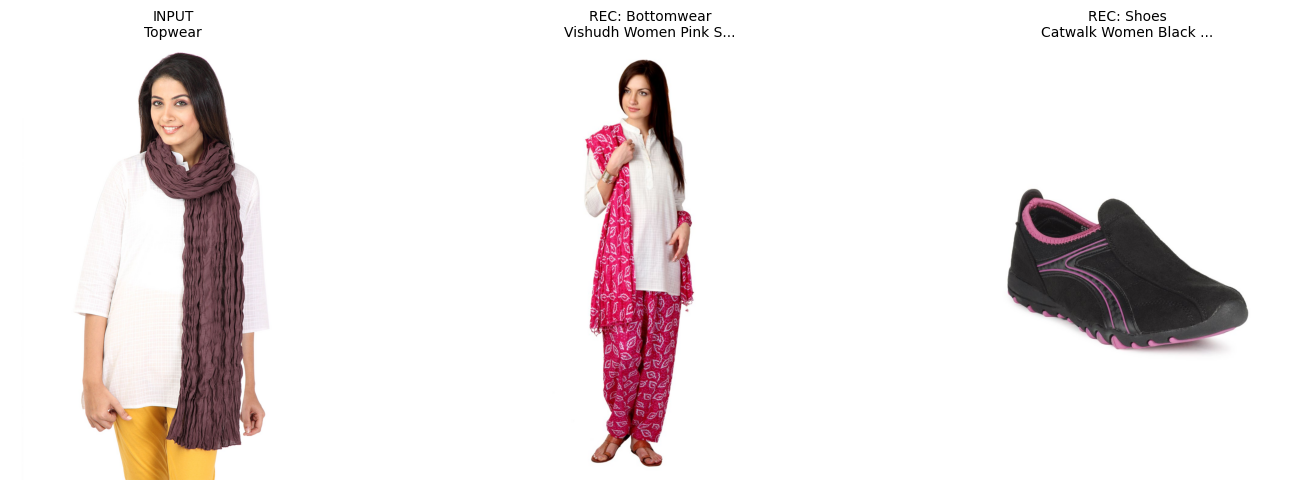

In [43]:
# 1. Pick a random item (e.g., index 10 - Brown Trousers)
test_idx = 799

# 2. Get recommendations using the filtered KNN logic
recs = recommend_outfit(test_idx, top_k=1)

# 3. View the outfit
plot_outfit(test_idx, recs)

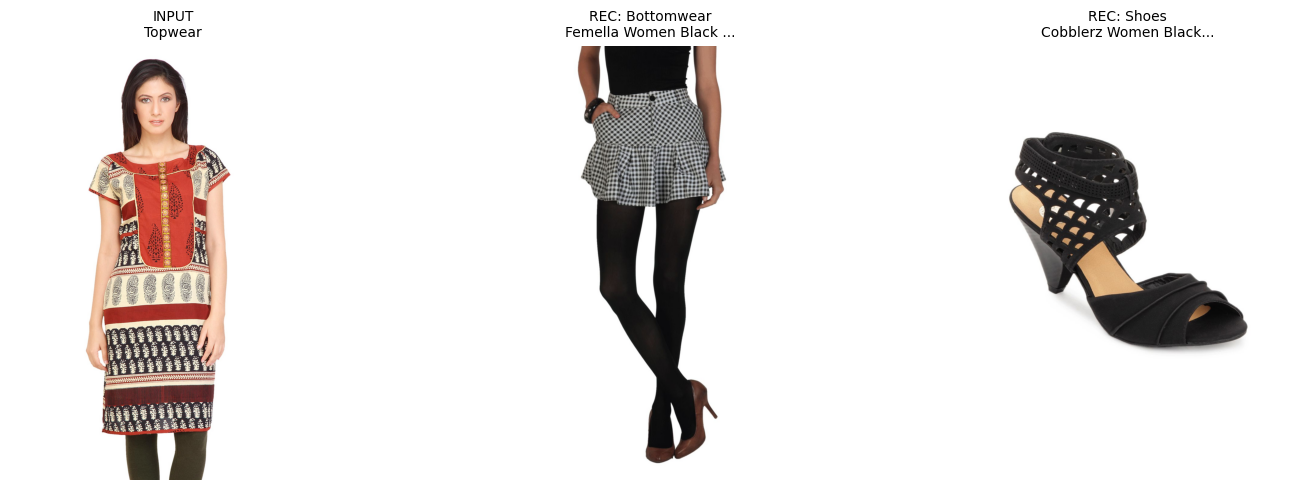

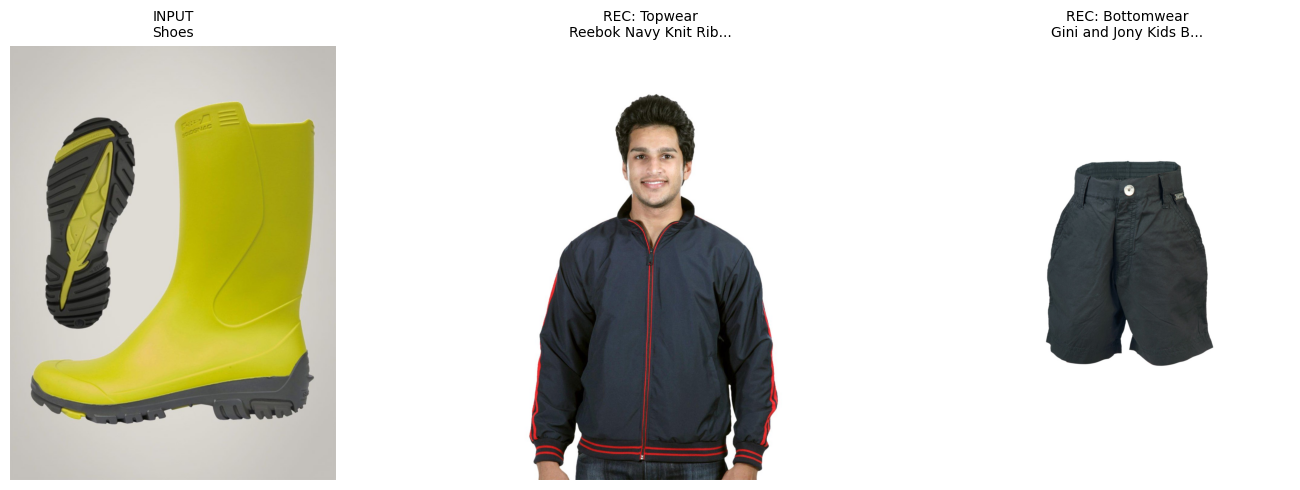

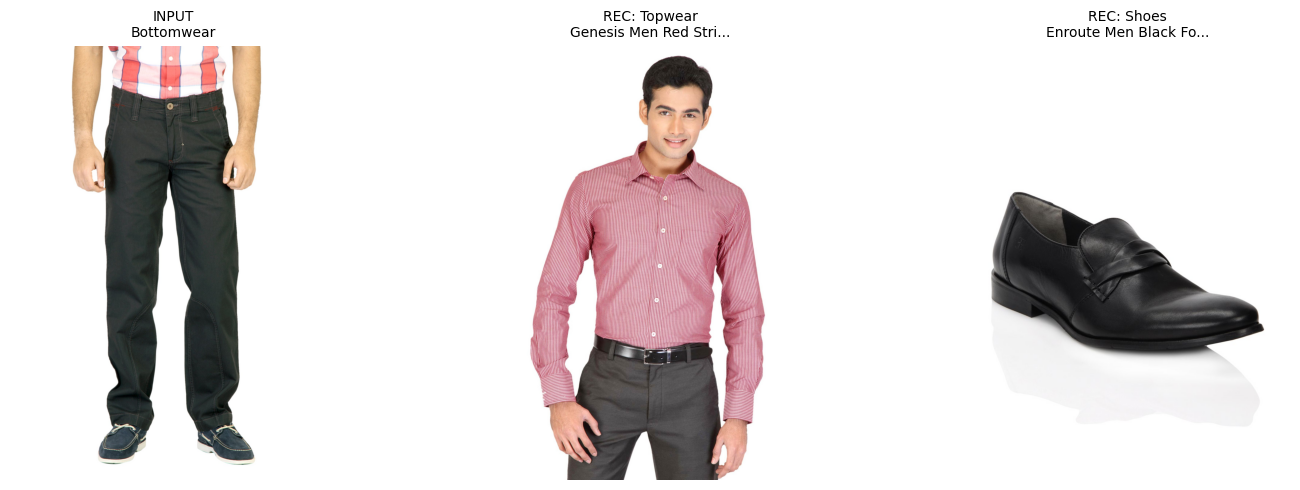

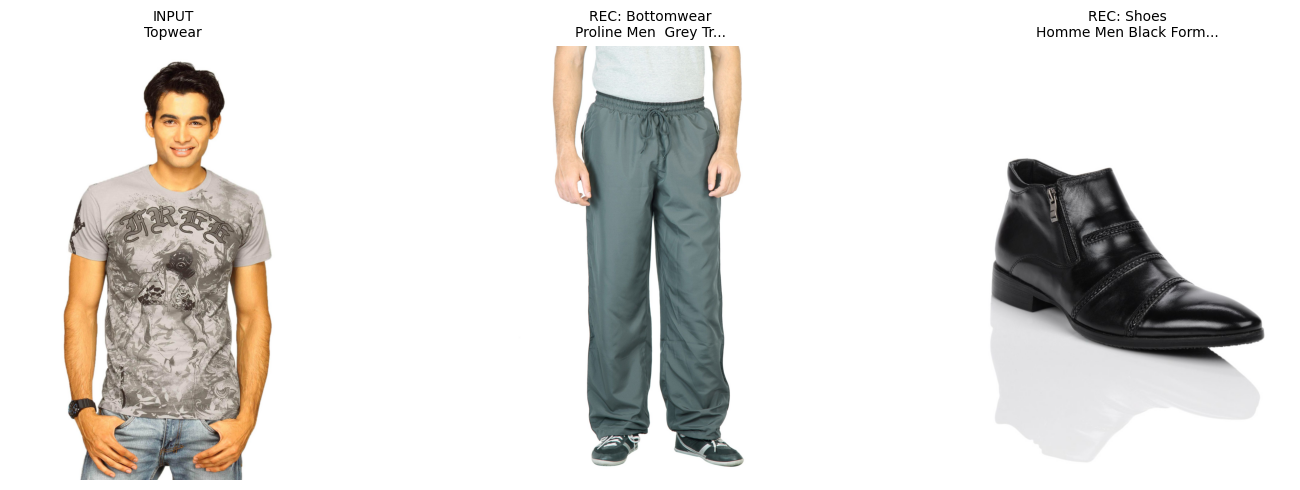

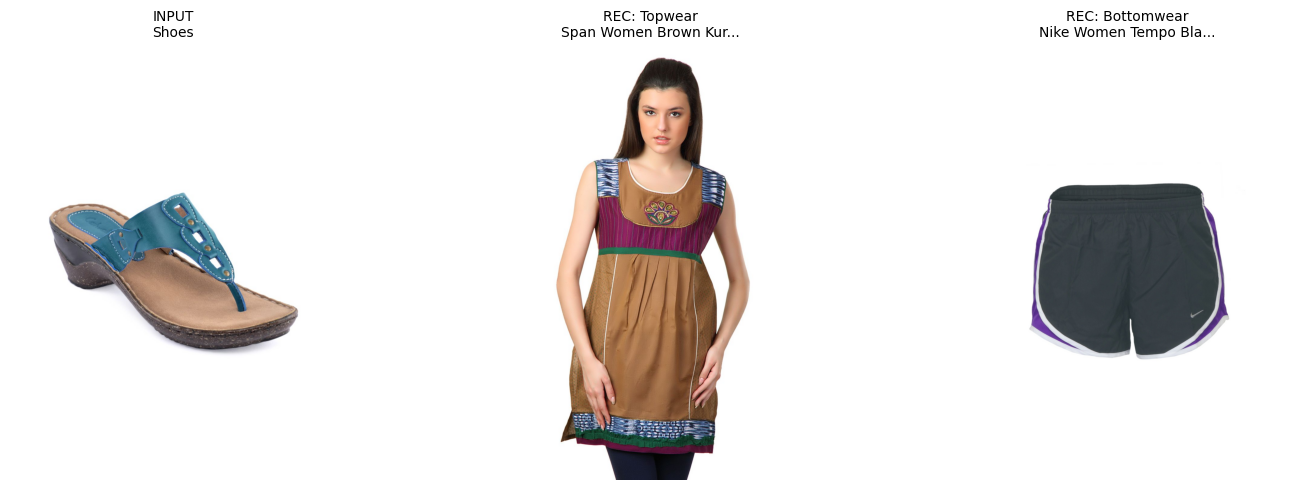

In [46]:
for i in np.random.choice(len(df_knn), 5, replace=False):
  recs = recommend_outfit(i, top_k=1)
  plot_outfit(i, recs)